In [671]:
import pandas as pd
import os

## 1. Load data

In [672]:
batch_path = os.getcwd()
path = os.path.join(batch_path, '..', 'Data', 'Housing.csv')
df = pd.read_csv(path)

In [673]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [674]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## 2. convert the x = data, y = label

In [675]:
X = df.drop(columns=['price', 'furnishingstatus'])
y = (df['price'] / 1000).astype(float)
 



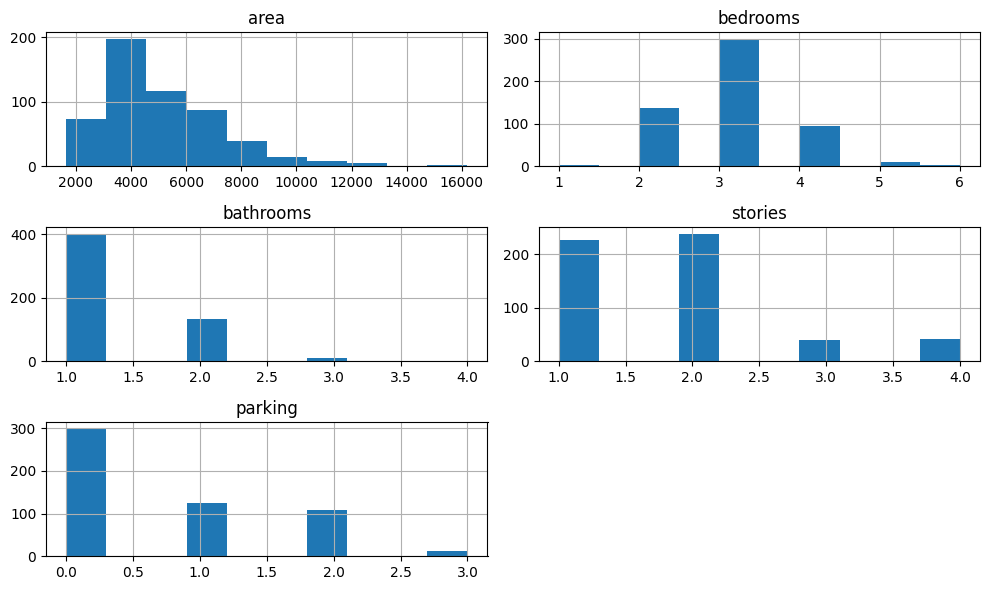

In [676]:
import matplotlib.pyplot as plt
X.hist(figsize=(10, 6))
plt.tight_layout()


In [677]:
cat_col = X.select_dtypes(include=('object')).columns
num_col = X.select_dtypes(include=(['int64', 'float64'])).columns

len(X.columns) == len(cat_col)+len(num_col)

True

In [678]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. label encoder

In [679]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
encoder = LabelEncoder()
for label in cat_col:
    X[label] = encoder.fit_transform(X[label])

X.head()
                   

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,1,0,0,0,1,2,1
1,8960,4,4,4,1,0,0,0,1,3,0
2,9960,3,2,2,1,0,1,0,0,2,1
3,7500,4,2,2,1,0,1,0,1,3,1
4,7420,4,1,2,1,1,1,0,1,2,0


In [680]:
X = X.astype(float)
y = y.astype(float)
 

## 4. trainin data spliting

In [681]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# covert the data in scaled from
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)


In [682]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)


## 5. model

In [683]:
from sklearn.ensemble import GradientBoostingRegressor
model_0 =  GradientBoostingRegressor()
model_0.fit(X_train, y_train_log)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [684]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

def predict_function(model, data, ans_log):
    # Convert predictions back to original scale (no int casting)
    y_pred = np.expm1(model.predict(data))
    
    # Convert true values back to original scale
    y_true = np.expm1(ans_log)
    
    # Model score (R^2) on log-transformed data
    score = model.score(data, ans_log)
    
    print('Model Score:', score)
    print('MAPE (%):', mean_absolute_percentage_error(y_true, y_pred) * 100)

    return y_pred




In [685]:
m = predict_function(model_0, X_test, y_test_log)

Model Score: 0.6482983934417543
MAPE (%): 20.76834047778153


In [686]:
pd.DataFrame({
    "true": y_test,
    "pred": m
}).sort_values("true").tail()


,true,pred
9,9800.0,7078.465158
10,9800.0,7120.089965
6,10150.0,12206.827830
2,12250.0,6470.661088
0,13300.0,9489.368014


In [687]:
df['area'].max(), df['area'].min()

(np.int64(16200), np.int64(1650))

In [688]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

# ===== 1️⃣ Prepare Data =====
# X: features, y: target
# Log-transform target
y_log = np.log1p(y)  # replace 'y' with your target array

# Train/test split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
 
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
# Convert Pandas Series to NumPy array
y_train_tensor = torch.tensor(y_train_log.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test_log.values, dtype=torch.float32).view(-1, 1)


train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

# ===== 2️⃣ Neural Network Model =====
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.model(x)

model = RegressionNN(X_train.shape[1])

# ===== 3️⃣ Training =====
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 200

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(train_loader):.4f}")

# ===== 4️⃣ Evaluation (MAPE) =====
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_tensor).numpy().flatten()
    y_pred = np.expm1(y_pred_log)      # convert back to original scale
    y_true = np.expm1(y_test_log)      # convert back to original scale
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print("MAPE (%):", mape)


Epoch 0, Loss: 65.6136
Epoch 20, Loss: 0.3894
Epoch 40, Loss: 0.1720
Epoch 60, Loss: 0.0960
Epoch 80, Loss: 0.0631
Epoch 100, Loss: 0.0455
Epoch 120, Loss: 0.0351
Epoch 140, Loss: 0.0317
Epoch 160, Loss: 0.0269
Epoch 180, Loss: 0.0260
MAPE (%): 26.812005110783304


In [689]:
y_pred[100:], y_true[100:]

(array([4919.101 , 6021.2407, 4444.305 , 8308.432 , 4034.1826, 3236.3364,
        7594.2617, 6303.6367, 5229.6665], dtype=float32),
 467    3010.0
 18     8890.0
 208    4900.0
 153    5530.0
 15     9100.0
 357    3773.0
 39     7910.0
 54     7350.0
 155    5530.0
 Name: price, dtype: float64)